In [1]:
import sys
import os
sys.path += [ f'{os.environ["HOME"]}/.local/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages' ]

# Now we can safely import atlasopenmagic
import atlasopenmagic as atom

In [2]:
import uproot # for reading .root files
import time # to measure time to analyse
import math # for mathematical functions such as square root
import awkward as ak # for handling complex and nested data structures efficiently
import numpy as np # # for numerical calculations such as histogramming
import matplotlib.pyplot as plt # for plotting
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel # for the signal and background fits
import vector #to use vectors
import requests # for HTTP access
import aiohttp # HTTP client support
import pandas as pd

In [3]:
atom.set_release('2025e-13tev-beta')

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 800.90datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [4]:
lumi = 36

In [5]:
# list with signal DSIDs: ee, mumu
# should tautau, bb, tt be included?
dsid_signal_list = [301209] 
dsid_background_list = [700323, 700324, 700325, 700470, 700471, 700472, 410219, 700589, 700602, 601624, 601628]
#dsid_background_list = [700324, 700325, 700470, 700471, 700472]

In [6]:
for dsid in dsid_background_list:
    print(dsid, atom.get_metadata(dsid, 'physics_short'))

# are these corect?

700323 Sh_2211_Zmumu_maxHTpTV2_BFilter
700324 Sh_2211_Zmumu_maxHTpTV2_CFilterBVeto
700325 Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto
700470 Sh_2211_Zmumu_maxHTpTV2_m10_40_pT5_BFilter
700471 Sh_2211_Zmumu_maxHTpTV2_m10_40_pT5_CFilterBVeto
700472 Sh_2211_Zmumu_maxHTpTV2_m10_40_pT5_CVetoBVeto
410219 aMcAtNloPythia8EvtGen_MEN30NLO_A14N23LO_ttmumu
700589 Sh_2212_llvvjj_os
700602 Sh_2212_llvv_os
601624 PhPy8EG_tW_DS_dyn_dil_antitop
601628 PhPy8EG_tW_DS_dyn_dil_top


In [7]:
def get_xsec_weight(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
        / metadata["sumOfWeights"]
    )

def get_N_inclusive(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
    )

def get_inclusive_yield(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
    )

def calc_weight(xsec_weight, weight_arr, data):
    for variable in weight_arr:
        xsec_weight = xsec_weight * data[variable]
    return xsec_weight

In [8]:
# functions to use at the start or end of a working session
# save current df as hdf5 or load saved hdf5 as df
def save_df(df_variables, df_labels, filename="blackbox_final.h5"):

    print(f"Saving DataFrame to {filename} ...")

    with pd.HDFStore(filename, mode="w") as store:
        store["variables"] = df_variables
        store["labels"] = df_labels

    print(f"Saved {len(df_variables)} events " f"to {filename}")


def load_df(filename="blackbox_final.h5"):

    if not os.path.exists(filename):
        raise FileNotFoundError(f"No HDF5 file found: {filename}")

    print(f"Loading DataFrame from {filename} ...")

    with pd.HDFStore(filename, mode="r") as store:
        df_variables = store["variables"]
        df_labels = store["labels"]

    print(f"Loaded {len(df_variables)} events " f"from {filename}")

    return df_variables, df_labels

In [9]:
def events_to_dataframe(data, variables, max_entries, default_values, label):

    result = {}

    for variable in variables:

        values = data[variable]

        # max entries for this variable
        n = max_entries[variable]

        # expand, cut to n entries
        values = ak.pad_none(values, n, clip=True)

        # replace missing entries with default value
        values = ak.fill_none(values, default_values[variable])

        # new column for each position
        for i in range(n):
            result[f"{variable}{i+1}"] = ak.to_numpy(values[:, i])

    # label
    result["label"] = label

    return pd.DataFrame(result)

In [10]:
# number of signal events, might be scaled up
metadata = atom.get_metadata(dsid_signal_list[0])
xsec_weight = get_xsec_weight(metadata, lumi)
signal_nevents = get_N_inclusive(metadata, lumi)
signal_nevents

63.784800000000004

In [11]:
background_yield_sum = 0
for dsid in dsid_background_list:
    metadata = atom.get_metadata(dsid)
    inc_yield = get_inclusive_yield(metadata, lumi)
    background_yield_sum = background_yield_sum + inc_yield

background_yield_sum

170264948.425092

In [12]:
variables = ["lep_pt", "lep_eta", "lep_phi", "lep_e", "jet_pt", "jet_eta", "jet_phi",]

max_entries = {"lep_pt": 4, "lep_eta": 4, "lep_phi": 4, "lep_e": 4, "jet_pt": 4, "jet_eta": 4, "jet_phi": 4,}

default_values = {"lep_pt": 0.0, "lep_eta": 0.0, "lep_phi": 0.0, "lep_e": 0.0, "jet_pt": 0.0, "jet_eta": 0.0, "jet_phi": 0.0,}

In [16]:
def create_blackbox(signal_dsid_list, background_dsid_list, variables, max_entries, default_values, signal_nevents, background_nevents, 
                    skim="noskim", checkpoint_file="blackbox.h5"):

    if os.path.exists(checkpoint_file):
        print(f"Load checkpoint: {checkpoint_file}")

        df = pd.read_hdf(checkpoint_file, key="events")

        checkpoint_info = pd.read_hdf(checkpoint_file, key="completed_dsid")

        completed_dsids = set(checkpoint_info["dsid"].astype(str))

        print(f"{len(df)} events loaded from checkpoint.")
        print(f"{len(completed_dsids)} DSIDs already processed.")
        print(f"Completed DSIDs: {completed_dsids}")


    else:

        print("No checkpoint found. Start from scratch.")

        # create empty DataFrame with the required columns
        columns = []

        for variable in variables:
            n = max_entries[variable]

            for i in range(n):
                columns.append(f"{variable}{i+1}")

        columns.append("label")

        df = pd.DataFrame({column: pd.Series(dtype="float64") for column in columns})

        df["label"] = pd.Series(dtype="int8")

        completed_dsids = set()

        print(f"Created empty DataFrame with columns:")
        print(df.columns.tolist())

    # calculate inclusive yield for each dsid
    yield_dict = {}
    signal_yield_sum = 0
    background_yield_sum = 0

    for dsid in signal_dsid_list:
        metadata = atom.get_metadata(dsid)
        inc_yield = get_inclusive_yield(metadata, lumi)
        yield_dict[dsid] = inc_yield
        signal_yield_sum = signal_yield_sum + inc_yield

    for dsid in background_dsid_list:
        metadata = atom.get_metadata(dsid)
        inc_yield = get_inclusive_yield(metadata, lumi)
        yield_dict[dsid] = inc_yield
        background_yield_sum = background_yield_sum + inc_yield


    def save_checkpoint():

        print("Save checkpoint ...")

        df.to_hdf(checkpoint_file, key="events", mode="w", format="table")

        completed_df = pd.DataFrame({"dsid": [str(dsid) for dsid in completed_dsids]})

        completed_df.to_hdf(checkpoint_file, key="completed_dsid", mode="a", format="table")

        print(f"Checkpoint saved: " f"{len(df)} Events, " f"{len(completed_dsids)} DSIDs")


    # calculate number of events for the blackbox for each dsid
    nevents_per_sample_dict = {}

    for dsid in signal_dsid_list:
        nevents_per_sample = signal_nevents / signal_yield_sum * yield_dict[dsid]
        nevents_per_sample_dict[dsid] = nevents_per_sample

    for dsid in background_dsid_list:
        nevents_per_sample = background_nevents / background_yield_sum * yield_dict[dsid]
        nevents_per_sample_dict[dsid] = nevents_per_sample

    # create blackbox
    for dsid, label in [(dsid, 1) for dsid in signal_dsid_list] + [(dsid, 0) for dsid in background_dsid_list]:

            dsid_str = str(dsid)

            print(f"\nCurrent DSID: {dsid}")
            print(f"Already processed: {dsid_str in completed_dsids}")

            if dsid_str in completed_dsids:
                print(f"DSID {dsid} already processed -> SKIP")
                continue
            
            target_events = int(nevents_per_sample_dict[dsid])
            remaining = target_events
            collected_events = 0
    
            file_list = atom.get_urls(dsid, skim, protocol='root', cache=False)
            print("filelist: ", file_list)
    
            #for url in atom.get_urls(dsid, protocol='root', cache=True):
            #    print("url: ", url)

            for afile in file_list:
                # Print which sample is being processed
                print(f'Processing file {afile} ({file_list.index(afile)+1}/{len(file_list)})')
                #print("afile: ", f'{afile}')
                print("target events: ", target_events)
    
                # Open file
                # tree = uproot.open(afile + ":analysis")
                #print("The information stored in the tree is:", tree.keys())
                # print("tree opened")

                # for data in tree.iterate(variables, library="ak", step_size=1000):
                for data in uproot.iterate(afile + ":analysis", variables, library="ak", step_size=100000):

                    # data = data[ak.num(data.lep_pt) == 2]

                    if len(data) == 0:
                        continue

                    if len(data) > remaining:
                        data = data[:remaining]


                    new_df = events_to_dataframe(data, variables, max_entries, default_values, label)

                    df = pd.concat([df, new_df], ignore_index=True)

                    collected_events += len(new_df)
                    remaining = target_events - collected_events

                    print("collected events: ", collected_events)
                    if collected_events >= target_events:
                        break
                    
                if collected_events >= target_events:
                    break

            completed_dsids.add(dsid_str)

            save_checkpoint()


    # shuffel the data frame
    df = df.sample(frac=1, random_state=25).reset_index(drop=True)

    # split df into variables and labels
    df_variables = df.drop(columns=["label"])
    df_labels = df["label"]

    return df_variables, df_labels

In [17]:
df_var, df_lab = create_blackbox(dsid_signal_list, dsid_background_list, variables, max_entries, default_values, 1000, 10000*1000, skim="2muons")
print("var: ", df_var)
print("lab: ", df_lab)

Load checkpoint: blackbox.h5
5396790 events loaded from checkpoint.
6 DSIDs already processed.
Completed DSIDs: {'301209', '700323', '700471', '700325', '700470', '700324'}

Current DSID: 301209
Already processed: True
DSID 301209 already processed -> SKIP

Current DSID: 700323
Already processed: True
DSID 700323 already processed -> SKIP

Current DSID: 700324
Already processed: True
DSID 700324 already processed -> SKIP

Current DSID: 700325
Already processed: True
DSID 700325 already processed -> SKIP

Current DSID: 700470
Already processed: True
DSID 700470 already processed -> SKIP

Current DSID: 700471
Already processed: True
DSID 700471 already processed -> SKIP

Current DSID: 700472
Already processed: False
filelist:  ['root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2muons_mc_700472.Sh_2211_Zmumu_maxHTpTV2_m10_40_pT5_CVetoBVeto.2muons.root']
Processing file root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2muons_m

In [18]:
df_var.head()

,lep_pt1,lep_pt2,lep_pt3,lep_pt4,lep_eta1,lep_eta2,lep_eta3,lep_eta4,lep_phi1,lep_phi2,...,jet_pt3,jet_pt4,jet_eta1,jet_eta2,jet_eta3,jet_eta4,jet_phi1,jet_phi2,jet_phi3,jet_phi4
0,134.376602,13.110909,0.0,0.0,-1.005529,-1.878655,0.0,0.0,1.547124,1.663192,...,0.000000,0.000000,0.996130,0.658251,0.000000,0.000000,-1.141779,-3.101511,0.000000,0.000000
1,14.210537,37.656036,0.0,0.0,-1.677363,-2.297657,0.0,0.0,1.960633,1.801892,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,11.058038,11.896707,0.0,0.0,1.800971,2.420784,0.0,0.0,-2.542701,0.471372,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,25.665413,79.573753,0.0,0.0,1.680899,2.227977,0.0,0.0,-3.022627,3.134852,...,0.000000,0.000000,1.204092,-0.879925,0.000000,0.000000,0.134992,1.164478,0.000000,0.000000
4,82.063759,64.680153,0.0,0.0,-1.490448,-1.548373,0.0,0.0,-0.283645,-0.626823,...,32.762558,24.977236,-0.521526,1.682640,1.328585,2.400496,-0.517685,-1.441519,-0.879041,-1.426909


In [19]:
df_var.describe()

,lep_pt1,lep_pt2,lep_pt3,lep_pt4,lep_eta1,lep_eta2,lep_eta3,lep_eta4,lep_phi1,lep_phi2,...,jet_pt3,jet_pt4,jet_eta1,jet_eta2,jet_eta3,jet_eta4,jet_phi1,jet_phi2,jet_phi3,jet_phi4
count,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,...,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07,1.000099e+07
mean,4.572065e+01,4.527846e+01,1.164194e+00,8.630687e-02,3.117075e-03,1.287976e-03,-3.617122e-05,-1.479439e-05,5.114428e-02,-5.315192e-02,...,8.879139e+00,3.006799e+00,4.331529e-03,3.704841e-03,2.904985e-03,1.504473e-03,5.930267e-03,2.667091e-03,2.295540e-03,1.392910e-03
std,5.198390e+01,5.012610e+01,1.327632e+01,3.966092e+00,1.284535e+00,1.399620e+00,1.955482e-01,4.685821e-02,1.811267e+00,1.808100e+00,...,2.127677e+01,1.055780e+01,1.111994e+00,8.974479e-01,6.389410e-01,4.181915e-01,1.588587e+00,1.236881e+00,8.646039e-01,5.609186e-01
min,7.000028e+00,7.000029e+00,0.000000e+00,0.000000e+00,-2.500000e+00,-2.500000e+00,-2.499921e+00,-2.499974e+00,-3.141589e+00,-3.141592e+00,...,0.000000e+00,0.000000e+00,-2.499981e+00,-2.499998e+00,-2.499936e+00,-2.499909e+00,-3.141591e+00,-3.141593e+00,-3.141591e+00,-3.141588e+00
25%,1.727534e+01,1.733562e+01,0.000000e+00,0.000000e+00,-1.178893e+00,-1.022636e+00,0.000000e+00,0.000000e+00,-1.516136e+00,-1.616885e+00,...,0.000000e+00,0.000000e+00,-6.785208e-01,0.000000e+00,0.000000e+00,0.000000e+00,-1.085608e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.154724e+01,3.139912e+01,0.000000e+00,0.000000e+00,6.871350e-02,-9.867812e-03,0.000000e+00,0.000000e+00,1.095444e-01,-9.026004e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,5.457816e+01,5.403992e+01,0.000000e+00,0.000000e+00,1.176474e+00,1.040432e+00,0.000000e+00,0.000000e+00,1.621705e+00,1.505875e+00,...,0.000000e+00,0.000000e+00,6.927947e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.106532e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,3.376526e+04,1.851302e+04,4.861080e+03,1.498687e+03,2.499995e+00,2.500000e+00,2.499997e+00,2.499810e+00,3.141592e+00,3.141593e+00,...,1.003541e+03,5.554596e+02,2.499995e+00,2.499998e+00,2.499981e+00,2.499864e+00,3.141592e+00,3.141587e+00,3.141592e+00,3.141585e+00


In [20]:
def calc_dilepton_mass(lep1_pt, lep1_eta, lep1_phi, lep1_e, lep2_pt, lep2_eta, lep2_phi, lep2_e):
    px_0 = lep1_pt*np.cos(lep1_phi) # x-component of lep[0] momentum
    py_0 = lep1_pt*np.sin(lep1_phi) # y-component of lep[0] momentum
    pz_0 = lep1_pt*np.sinh(lep1_eta) # z-component of lep[0] momentum
    px_1 = lep2_pt*np.cos(lep2_phi) # x-component of lep[1] momentum
    py_1 = lep2_pt*np.sin(lep2_phi) # y-component of lep[1] momentum
    pz_1 = lep2_pt*np.sinh(lep2_eta) # z-component of lep[1] momentum
    sumpx = px_0 + px_1 # x-component of 4-lepton momentum
    sumpy = py_0 + py_1 # y-component of 4-lepton momentum
    sumpz = pz_0 + pz_1 # z-component of 4-lepton momentum
    sumE = lep1_e + lep2_e # energy of 4-lepton system
    rad = sumE**2 - sumpx**2 - sumpy**2 - sumpz**2
    rad = np.maximum(rad, 0)
    return np.sqrt(rad) #/1000 to go from MeV to GeV

def calc_leading_lep_pt(lep_pt_list):
    return lep_pt_list.max(axis=1)


def calc_subleading_lep_pt(lep_pt_list):
    return lep_pt_list.apply(lambda row: row.nlargest(2).iloc[-1], axis=1)


def calc_leading_lep_var(lep_pt_list, lep_var_list):
    leading_idx = lep_pt_list.values.argmax(axis=1)
    return lep_var_list.values[range(len(lep_var_list)), leading_idx]

def calc_subleading_lep_var(lep_pt_list, lep_var_list):
    subleading_idx = lep_pt_list.values.argsort(axis=1)[:, -2]

    return lep_var_list.values[range(len(lep_var_list)), subleading_idx]


def calc_deltaR(deltaeta, deltaphi):
    return np.sqrt(deltaeta**2 + deltaphi**2)

def calc_delta_phi(leading_lep_phi, subleading_lep_phi):
    deltaphi = leading_lep_phi - subleading_lep_phi
    deltaphi = np.abs(leading_lep_phi - subleading_lep_phi)
    deltaphi = np.where(deltaphi > 2.0 * np.pi, deltaphi - 2.0 * np.pi, deltaphi)
    deltaphi = np.where(deltaphi >= np.pi, 2.0 * np.pi - deltaphi, deltaphi)
    return deltaphi / np.pi


def calc_delta_eta(leading_lep_eta, subleading_lep_eta):
    deltaeta = np.abs(leading_lep_eta - subleading_lep_eta)
    return deltaeta

In [21]:
# calculate (sub-) leading lepton variables

df_var["leading_lep_pt"] = calc_leading_lep_pt(df_var[["lep_pt1", "lep_pt2", "lep_pt3", "lep_pt4"]])
df_var["subleading_lep_pt"] = calc_subleading_lep_pt(df_var[["lep_pt1", "lep_pt2", "lep_pt3", "lep_pt4"]])
df_var["leading_lep_eta"] = calc_leading_lep_var(df_var[["lep_pt1", "lep_pt2", "lep_pt3", "lep_pt4"]], 
                                                df_var[["lep_eta1", "lep_eta2", "lep_eta3", "lep_eta4"]])
df_var["subleading_lep_eta"] = calc_subleading_lep_var(df_var[["lep_pt1", "lep_pt2", "lep_pt3", "lep_pt4"]], 
                                                df_var[["lep_eta1", "lep_eta2", "lep_eta3", "lep_eta4"]])
df_var["leading_lep_phi"] = calc_leading_lep_var(df_var[["lep_pt1", "lep_pt2", "lep_pt3", "lep_pt4"]], 
                                                df_var[["lep_phi1", "lep_phi2", "lep_phi3", "lep_phi4"]])
df_var["subleading_lep_phi"] = calc_subleading_lep_var(df_var[["lep_pt1", "lep_pt2", "lep_pt3", "lep_pt4"]], 
                                                df_var[["lep_phi1", "lep_phi2", "lep_phi3", "lep_phi4"]])
df_var["leading_lep_e"] = calc_leading_lep_var(df_var[["lep_pt1", "lep_pt2", "lep_pt3", "lep_pt4"]], 
                                                df_var[["lep_e1", "lep_e2", "lep_e3", "lep_e4"]])
df_var["subleading_lep_e"] = calc_subleading_lep_var(df_var[["lep_pt1", "lep_pt2", "lep_pt3", "lep_pt4"]], 
                                                df_var[["lep_e1", "lep_e2", "lep_e3", "lep_e4"]])

df_var["mass"] = calc_dilepton_mass(df_var["leading_lep_pt"], df_var["leading_lep_eta"], df_var["leading_lep_phi"], df_var["leading_lep_e"], 
                                        df_var["subleading_lep_pt"], df_var["subleading_lep_eta"], df_var["subleading_lep_phi"], df_var["subleading_lep_e"])

df_var["deltaPhi"] = calc_delta_phi(df_var["leading_lep_phi"], df_var["subleading_lep_phi"])
df_var["deltaEta"] = calc_delta_phi(df_var["leading_lep_eta"], df_var["subleading_lep_eta"])
df_var["deltaR"] = calc_delta_phi(df_var["leading_lep_eta"], df_var["subleading_lep_phi"])

df_var.head()

,lep_pt1,lep_pt2,lep_pt3,lep_pt4,lep_eta1,lep_eta2,lep_eta3,lep_eta4,lep_phi1,lep_phi2,...,leading_lep_eta,subleading_lep_eta,leading_lep_phi,subleading_lep_phi,leading_lep_e,subleading_lep_e,mass,deltaPhi,deltaEta,deltaR
0,134.376602,13.110909,0.0,0.0,-1.005529,-1.878655,0.0,0.0,1.547124,1.663192,...,-1.005529,-1.878655,1.547124,1.663192,208.230286,43.905247,38.136881,0.036946,0.277925,0.849480
1,14.210537,37.656036,0.0,0.0,-1.677363,-2.297657,0.0,0.0,1.960633,1.801892,...,-2.297657,-1.677363,1.801892,1.960633,189.246643,39.351192,15.036963,0.050529,0.197446,0.644544
2,11.058038,11.896707,0.0,0.0,1.800971,2.420784,0.0,0.0,-2.542701,0.471372,...,2.420784,1.800971,0.471372,-2.542701,67.475433,34.394310,24.006430,0.959409,0.197293,0.420074
3,25.665413,79.573753,0.0,0.0,1.680899,2.227977,0.0,0.0,-3.022627,3.134852,...,2.227977,1.680899,3.134852,-3.022627,373.551758,71.306114,25.670177,0.040013,0.174140,0.328681
4,82.063759,64.680153,0.0,0.0,-1.490448,-1.548373,0.0,0.0,-0.283645,-0.626823,...,-1.490448,-1.548373,-0.283645,-0.626823,191.387360,158.996887,25.236064,0.109237,0.018438,0.274901


In [22]:
def plot_variable(df_var, df_lab, var, min, max, xlabel, save, xlog=True, ylog=True):
    plt.figure(figsize=(8, 5))

    # bins
    if xlog:
        bins = np.logspace(np.log10(min), np.log10(max), 50)
    else:
        bins = np.linspace(min, max, 50)

    # choose range
    signal = df_var[
        (df_lab == 1) &
        (df_var[var] >= min) &
        (df_var[var] <= max)
    ]

    background = df_var[
        (df_lab == 0) &
        (df_var[var] >= min) &
        (df_var[var] <= max)
    ]

    print(f"Background integral = {len(background)}")
    print(f"Signal     integral = {len(signal)}")

    plt.hist(
        [signal[var], background[var]],
        bins=bins,
        stacked=True,
        label=["Z'", "Background"],
        histtype="bar"
    )

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Events", fontsize=16)

    plt.tick_params(axis="both",which="major",labelsize=14)


    if xlog:
        plt.xscale("log")

    if ylog:
        plt.yscale("log")

    plt.xlim(min, max)
    plt.legend(fontsize=13)

    if save is not None:
        plt.savefig(save, bbox_inches="tight")

    plt.show()

In [23]:
plot_variables = [
    ("mass",               1,       70000, r"$m_{\ell\ell}$ [GeV]",          "mass.pdf",               True, True),
    ("leading_lep_pt",     5,       90000, r"Leading lepton $p_T$ [GeV]",    "leading_lep_pt.pdf",    True, True),
    ("subleading_lep_pt",  5,       4000, r"Subleading lepton $p_T$ [GeV]", "subleading_lep_pt.pdf", True, True),
    ("leading_lep_eta",   -3,          3, r"Leading lepton $\eta$",         "leading_lep_eta.pdf",   False, False),
    ("subleading_lep_eta",-3,          3, r"Subleading lepton $\eta$",      "subleading_lep_eta.pdf",False, False),
    ("leading_lep_phi",   -np.pi, np.pi, r"Leading lepton $\varphi$",          "leading_lep_phi.pdf",   False, False),
    ("subleading_lep_phi",-np.pi, np.pi, r"Subleading lepton $\varphi$",       "subleading_lep_phi.pdf", False, False),
    ("leading_lep_e",      5,       90000, r"Leading lepton $E$ [GeV]",       "leading_lep_e.pdf",     True, True),
    ("subleading_lep_e",   5,       8000, r"Subleading lepton $E$ [GeV]",    "subleading_lep_e.pdf",  True, True),
    ("deltaPhi",           0,     np.pi, r"$\Delta\varphi$",                   "deltaPhi.pdf",          False, True),
    ("deltaEta",           0,          6, r"$\Delta\eta$",                  "deltaEta.pdf",          False, True),
    ("deltaR",             0,          6, r"$\Delta R$",                    "deltaR.pdf",            False, True),
]

Background integral = 9999513
Signal     integral = 1000


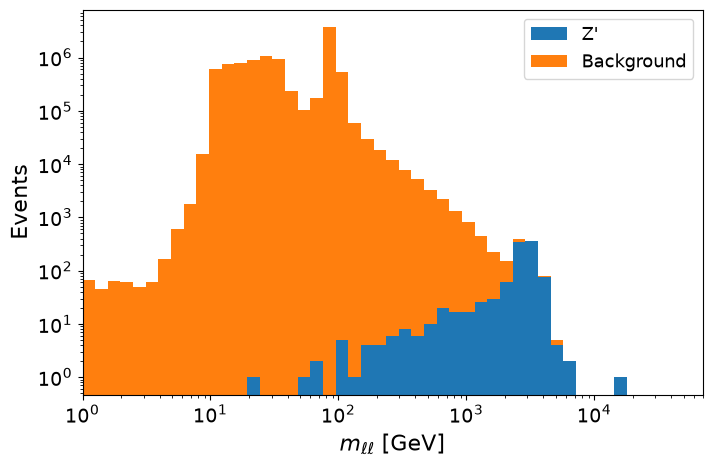

Background integral = 9999994
Signal     integral = 1000


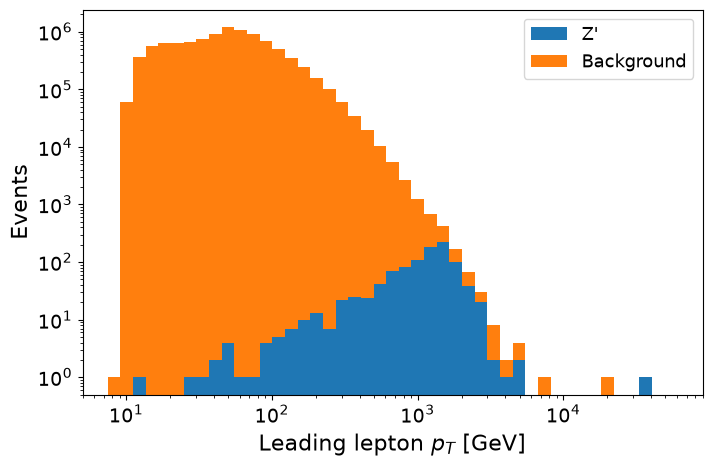

Background integral = 9999994
Signal     integral = 1000


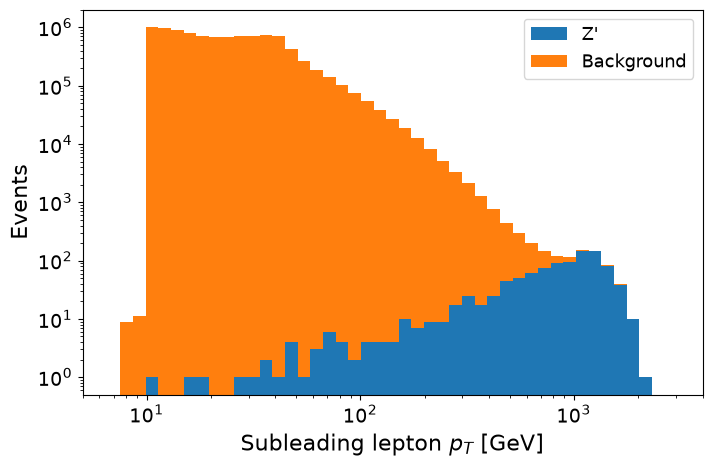

Background integral = 9999994
Signal     integral = 1000


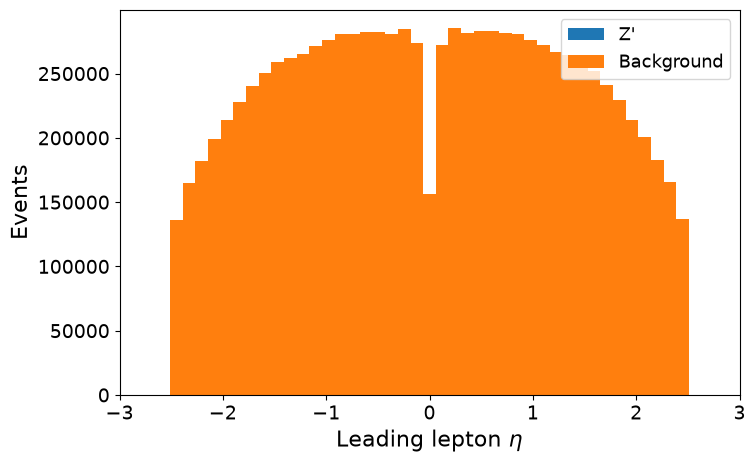

Background integral = 9999994
Signal     integral = 1000


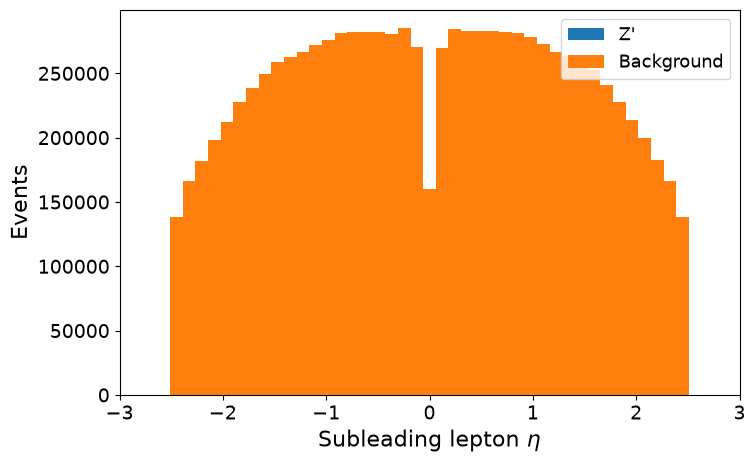

Background integral = 9999994
Signal     integral = 1000


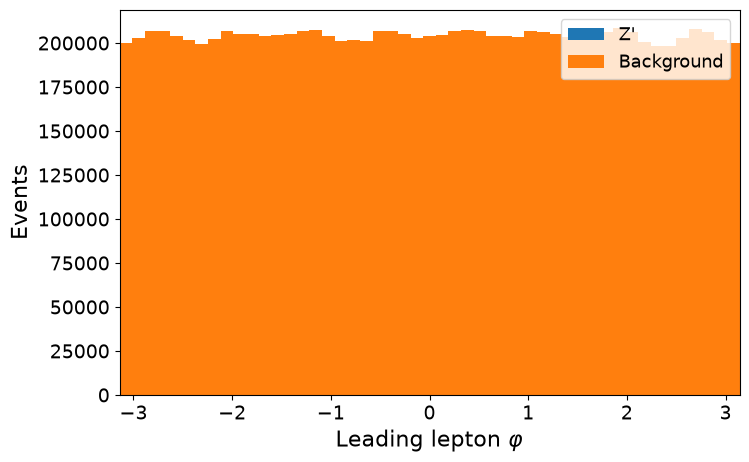

Background integral = 9999994
Signal     integral = 1000


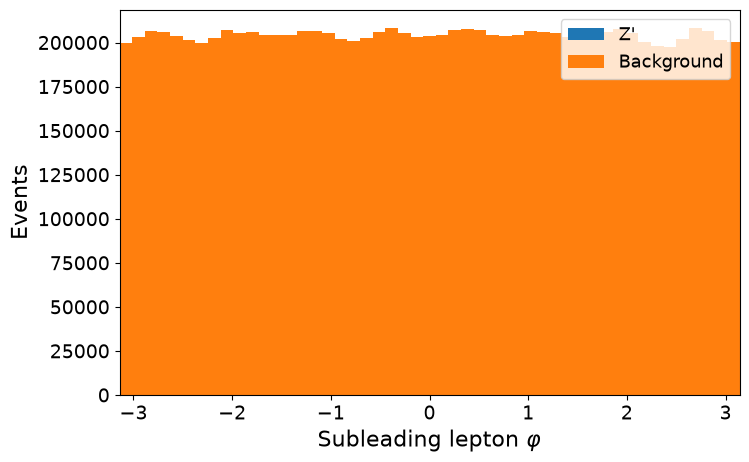

Background integral = 9999994
Signal     integral = 1000


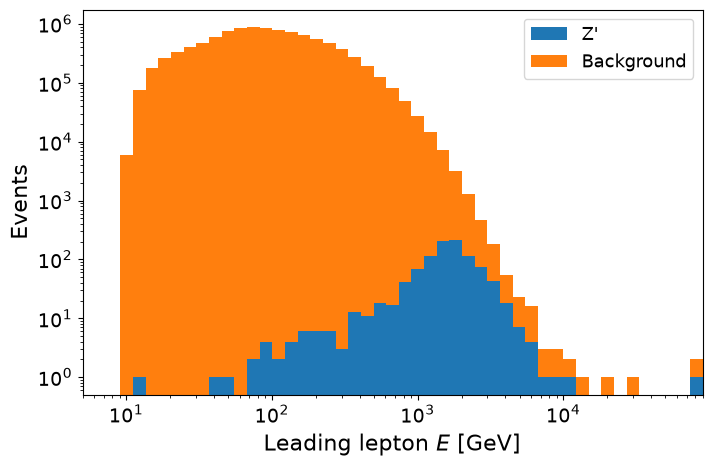

Background integral = 9999994
Signal     integral = 1000


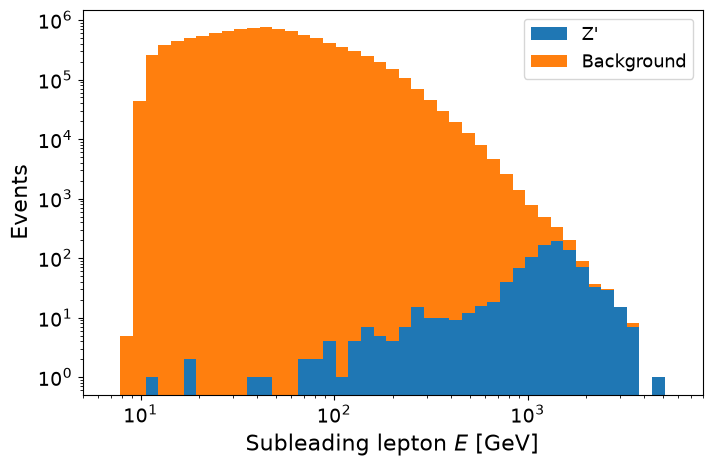

Background integral = 9999994
Signal     integral = 1000


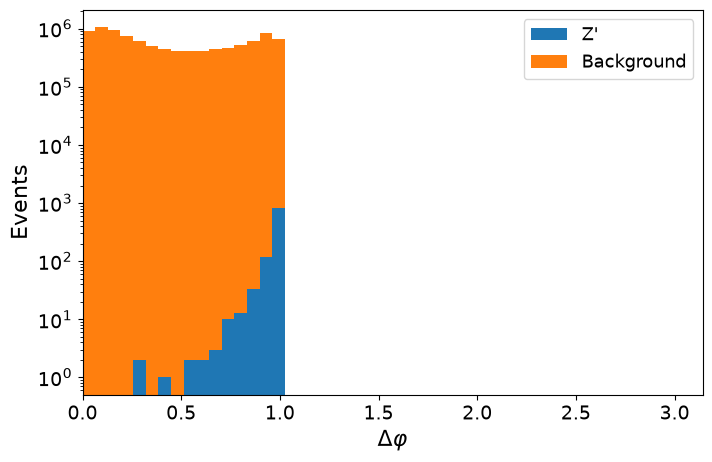

Background integral = 9999994
Signal     integral = 1000


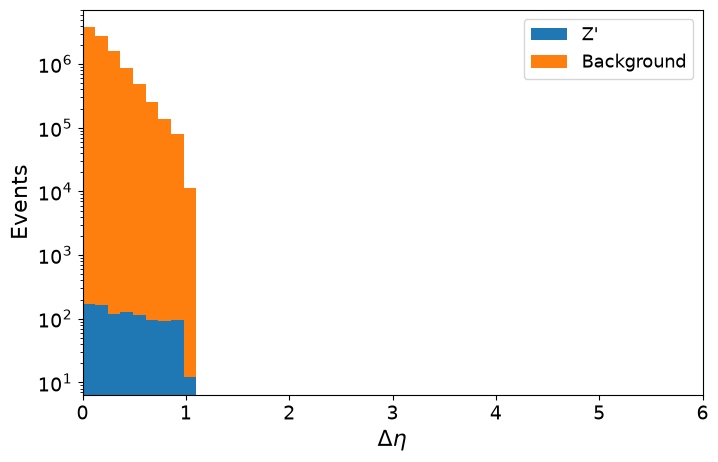

Background integral = 9999994
Signal     integral = 1000


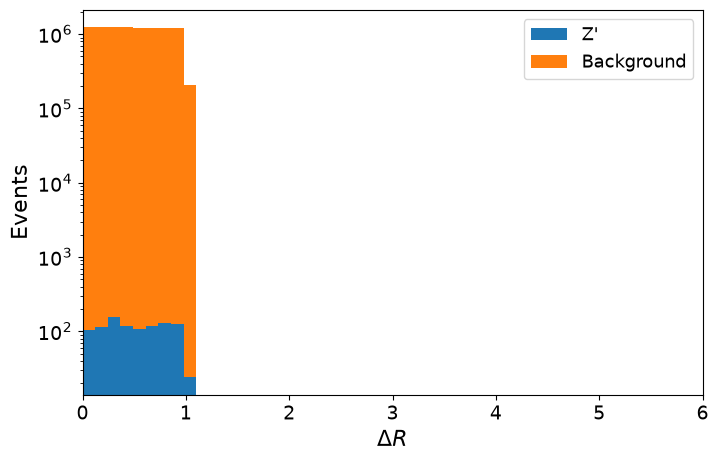

In [24]:
for var, min_val, max_val, xlabel, filename, xlog, ylog in plot_variables:
    plot_variable(df_var,df_lab, var=var, min=min_val, max=max_val, xlabel=xlabel, save="bb_"+filename, xlog=xlog, ylog=ylog)

In [25]:
print(df_var.columns)

Index(['lep_pt1', 'lep_pt2', 'lep_pt3', 'lep_pt4', 'lep_eta1', 'lep_eta2',
       'lep_eta3', 'lep_eta4', 'lep_phi1', 'lep_phi2', 'lep_phi3', 'lep_phi4',
       'lep_e1', 'lep_e2', 'lep_e3', 'lep_e4', 'jet_pt1', 'jet_pt2', 'jet_pt3',
       'jet_pt4', 'jet_eta1', 'jet_eta2', 'jet_eta3', 'jet_eta4', 'jet_phi1',
       'jet_phi2', 'jet_phi3', 'jet_phi4', 'leading_lep_pt',
       'subleading_lep_pt', 'leading_lep_eta', 'subleading_lep_eta',
       'leading_lep_phi', 'subleading_lep_phi', 'leading_lep_e',
       'subleading_lep_e', 'mass', 'deltaPhi', 'deltaEta', 'deltaR'],
      dtype='str')


In [26]:
save_df(df_var, df_lab)

Saving DataFrame to blackbox_final.h5 ...
Saved 10000994 events to blackbox_final.h5
